# Modélisation 

### Import des modules 

In [351]:
# Bibliothèques
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Supprimer les warnings
warnings.filterwarnings('ignore')

#Selection
from sklearn.model_selection import (
    train_test_split,
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 

#Modèles
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor


### Import des données

In [352]:
# Charger les données nettoyées
building_consumption_encoded = pd.read_csv('./sources/2016_Building_Energy_Benchmarking_03_encoded.csv')
X = pd.read_csv('./sources/2016_Building_Energy_Benchmarking_03X_building_consumption.csv')
X_scaled = pd.read_csv('./sources/2016_Building_Energy_Benchmarking_03X_scaled_building_consumption.csv')
y = pd.read_csv('./sources/2016_Building_Energy_Benchmarking_03y_building_consumption.csv')

# Créer une version 1D de y pour éviter les warnings sklearn
y_ravel = y.values.ravel()

#print(f"Dataset original : {building_consumption_encoded.shape}")
#print(f"\nAperçu des données :")
#display(building_consumption_encoded.head())
#print(f"\nTypes de données :")
#display(building_consumption_encoded.dtypes)
#print(f"Shape de y (DataFrame) : {y.shape}")
#print(f"Shape de y_ravel (array 1D) : {y_ravel.shape}")

---

### Comparaison de différents modèles supervisés

A réaliser :
* Pour chaque algorithme que vous allez tester, vous devez :
    * Réaliser au préalable une séparation en jeu d'apprentissage et jeu de test via une validation croisée.
    * Si les features quantitatives que vous souhaitez utiliser ont des ordres de grandeur très différents les uns des autres, et que vous utilisez un algorithme de regression qui est sensible à cette différence, alors il faut réaliser un scaling (normalisation) de la donnée au préalable.
    * Entrainer le modèle sur le jeu de Train
    * Prédire la cible sur la donnée de test (nous appelons cette étape, l'inférence).
    * Calculer les métriques de performance R2, MAE et RMSE sur le jeu de train et de test.
    * Interpréter les résultats pour juger de la fiabilité de l'algorithme.
* Vous pouvez choisir par exemple de tester un modèle linéaire, un modèle à base d'arbres et un modèle de type SVM
* Déterminer le modèle le plus performant parmi ceux testés.

---

### 1- Test d'un modèle à régression linéaire :

In [353]:
# Séparer les données en ensembles d'entraînement et de test (20% de tests)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Séparer les données en ensembles d'entraînement et de test scaled (20% de tests)
X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Afficher les dimensions des ensembles
print(f"Dimensions de l'ensemble d'entraînement : X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Dimensions de l'ensemble de test : X_test: {X_test.shape}, y_test: {y_test.shape}")

# Afficher les dimensions des ensembles scaled
print(f"\n\n==" + "Dimensions de l'ensemble d'entraînement : X_train_scaled: {X_train_scaled.shape}, y_train: {y_train.shape}")
print(f"Dimensions de l'ensemble de test : X_test_scaled: {X_test_scaled.shape}, y_test: {y_test.shape}")

Dimensions de l'ensemble d'entraînement : X_train: (1021, 41), y_train: (1021, 1)
Dimensions de l'ensemble de test : X_test: (256, 41), y_test: (256, 1)


==Dimensions de l'ensemble d'entraînement : X_train_scaled: {X_train_scaled.shape}, y_train: {y_train.shape}
Dimensions de l'ensemble de test : X_test_scaled: (256, 41), y_test: (256, 1)


#### 1.1 Entraînement du modèle de régression linéaire

In [354]:
################## DONNÉES BRUTES ##################
# Créer et entraîner le modèle de régression linéaire
lr_model = LinearRegression()

# Entraîner le modèle sur les données d'entraînement
lr_model.fit(X_train, y_train)

print("=" * 100)
print("MODÈLE DE RÉGRESSION LINÉAIRE SUR DONNÉES BRUTES - ENTRAÎNÉ")
print("=" * 100)
print(f"Nombre de features utilisées : {lr_model.n_features_in_}")
print(f"Intercept (constante) : {lr_model.intercept_[0]:,.2f}")
print(f"\nTop 5 coefficients les plus importants (en valeur absolue) :")

# Afficher les coefficients les plus importants
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_[0]
})
coef_df['Abs_Coefficient'] = abs(coef_df['Coefficient'])
coef_df_sorted = coef_df.sort_values('Abs_Coefficient', ascending=False)

for i, row in coef_df_sorted.head(5).iterrows():
    print(f"  {row['Feature']}: {row['Coefficient']:,.2f}")

################## DONNÉES NORMALISÉES ##################
# Créer et entraîner le modèle de régression linéaire
lr_model_scaled = LinearRegression()

# Entraîner le modèle sur les données d'entraînement scaled
lr_model_scaled.fit(X_train_scaled, y_train)

print("\n\n" + "=" * 100)
print("MODÈLE DE RÉGRESSION LINÉAIRE SUR DONNÉES NORMALISÉES - ENTRAÎNÉ")
print("=" * 100)
print(f"Nombre de features utilisées : {lr_model_scaled.n_features_in_}")
print(f"Intercept (constante) : {lr_model_scaled.intercept_[0]:,.2f}")
print(f"\nTop 5 coefficients les plus importants (en valeur absolue) :")

# Afficher les coefficients les plus importants
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model_scaled.coef_[0]
})
coef_df['Abs_Coefficient'] = abs(coef_df['Coefficient'])
coef_df_sorted = coef_df.sort_values('Abs_Coefficient', ascending=False)

for i, row in coef_df_sorted.head(5).iterrows():
    print(f"  {row['Feature']}: {row['Coefficient']:,.2f}")

MODÈLE DE RÉGRESSION LINÉAIRE SUR DONNÉES BRUTES - ENTRAÎNÉ
Nombre de features utilisées : 41
Intercept (constante) : -1,710.47

Top 5 coefficients les plus importants (en valeur absolue) :
  PrimaryPropertyType_University: 31,147.89
  PrimaryPropertyType_Refrigerated Warehouse: -13,890.57
  PrimaryPropertyType_Supermarket / Grocery Store: -11,471.88
  PrimaryPropertyType_Mixed Use Property: 11,303.21
  GHGEmissionsIntensity: -9,844.13


MODÈLE DE RÉGRESSION LINÉAIRE SUR DONNÉES NORMALISÉES - ENTRAÎNÉ
Nombre de features utilisées : 41
Intercept (constante) : 1,036,542.52

Top 5 coefficients les plus importants (en valeur absolue) :
  Electricity(kWh): 703,640.49
  TotalGHGEmissions: 363,605.22
  NaturalGas(kWh): 130,516.81
  Densite_energetique: 18,692.02
  GHGEmissionsIntensity: -18,147.31


#### 1.2 Prédictions sur les ensembles Train et Test

In [355]:
################## DONNÉES BRUTES ##################
# Faire des prédictions sur les ensembles d'entraînement et de test
y_train_pred_lr = lr_model.predict(X_train)
y_test_pred_lr = lr_model.predict(X_test)

print("=" * 100)
print("PRÉDICTIONS RÉALISÉES")
print("=" * 100)
print(f"Prédictions sur Train : {len(y_train_pred_lr)} échantillons")
print(f"Prédictions sur Test : {len(y_test_pred_lr)} échantillons")

# Afficher quelques exemples de prédictions vs valeurs réelles
print(f"\n{'='*100}")
print("EXEMPLES DE PRÉDICTIONS (Test Set)")
print(f"{'='*100}")
comparison_df = pd.DataFrame({
    'Réel': y_test.values.flatten()[:5],
    'Prédit': y_test_pred_lr.flatten()[:5],
    'Erreur': y_test.values.flatten()[:5] - y_test_pred_lr.flatten()[:5]
})
comparison_df['Erreur %'] = (comparison_df['Erreur'] / comparison_df['Réel'] * 100).round(2)
display(comparison_df)

################## DONNÉES NORMALISÉES ##################
# Faire des prédictions sur les ensembles d'entraînement et de test
y_train_pred_lr_scaled = lr_model_scaled.predict(X_train_scaled)
y_test_pred_lr_scaled = lr_model_scaled.predict(X_test_scaled)

print("\n\n" + "=" * 100)
print("PRÉDICTIONS RÉALISÉES SUR DONNÉES NORMALISÉES")
print("=" * 100)
print(f"Prédictions sur Train : {len(y_train_pred_lr_scaled)} échantillons")
print(f"Prédictions sur Test : {len(y_test_pred_lr_scaled)} échantillons")

# Afficher quelques exemples de prédictions vs valeurs réelles
print(f"\n{'='*100}")
print("EXEMPLES DE PRÉDICTIONS SUR DONNÉES NORMALISÉES (Test Set)")
print(f"{'='*100}")
comparison_df_scaled = pd.DataFrame({
    'Réel': y_test.values.flatten()[:5],
    'Prédit': y_test_pred_lr_scaled.flatten()[:5],
    'Erreur': y_test.values.flatten()[:5] - y_test_pred_lr_scaled.flatten()[:5]
})
comparison_df_scaled['Erreur %'] = (comparison_df_scaled['Erreur'] / comparison_df_scaled['Réel'] * 100).round(2)
display(comparison_df_scaled)

PRÉDICTIONS RÉALISÉES
Prédictions sur Train : 1021 échantillons
Prédictions sur Test : 256 échantillons

EXEMPLES DE PRÉDICTIONS (Test Set)


,Réel,Prédit,Erreur,Erreur %
0,2.281136e+05,2.243020e+05,3811.581770,1.67
1,4.044183e+05,4.049458e+05,-527.519057,-0.13
2,5.540516e+05,5.693928e+05,-15341.188826,-2.77
3,1.863238e+06,1.871655e+06,-8416.893709,-0.45
4,1.221024e+06,1.224707e+06,-3682.676785,-0.30




PRÉDICTIONS RÉALISÉES SUR DONNÉES NORMALISÉES
Prédictions sur Train : 1021 échantillons
Prédictions sur Test : 256 échantillons

EXEMPLES DE PRÉDICTIONS SUR DONNÉES NORMALISÉES (Test Set)


,Réel,Prédit,Erreur,Erreur %
0,2.281136e+05,2.243020e+05,3811.581769,1.67
1,4.044183e+05,4.049458e+05,-527.519057,-0.13
2,5.540516e+05,5.693928e+05,-15341.188826,-2.77
3,1.863238e+06,1.871655e+06,-8416.893709,-0.45
4,1.221024e+06,1.224707e+06,-3682.676784,-0.30


#### 1.3 Calcul des métriques de performance

In [356]:
################## DONNÉES BRUTES ##################
# Calculer les métriques pour l'ensemble d'entraînement
r2_train_lr = r2_score(y_train, y_train_pred_lr)
mae_train_lr = mean_absolute_error(y_train, y_train_pred_lr)
rmse_train_lr = np.sqrt(mean_squared_error(y_train, y_train_pred_lr))

# Calculer les métriques pour l'ensemble de test
r2_test_lr = r2_score(y_test, y_test_pred_lr)
mae_test_lr = mean_absolute_error(y_test, y_test_pred_lr)
rmse_test_lr = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))

# Afficher les résultats
print("=" * 100)
print("MÉTRIQUES DE PERFORMANCE - RÉGRESSION LINÉAIRE")
print("=" * 100)

print("\nENSEMBLE D'ENTRAÎNEMENT (Train)")
print("-" * 100)
print(f"  R² Score    : {r2_train_lr:.4f}")
print(f"  MAE         : {mae_train_lr:,.2f} kWh")
print(f"  RMSE        : {rmse_train_lr:,.2f} kWh")

print("\nENSEMBLE DE TEST (Test)")
print("-" * 100)
print(f"  R² Score    : {r2_test_lr:.4f}")
print(f"  MAE         : {mae_test_lr:,.2f} kWh")
print(f"  RMSE        : {rmse_test_lr:,.2f} kWh")

# Calculer l'écart entre train et test pour détecter le surapprentissage
print("\nANALYSE DU SURAPPRENTISSAGE")
print("-" * 100)
diff_r2 = r2_train_lr - r2_test_lr
diff_mae = mae_train_lr - mae_test_lr
diff_rmse = rmse_train_lr - rmse_test_lr

print(f"  Écart R² (Train - Test)    : {diff_r2:.4f}")
print(f"  Écart MAE (Train - Test)   : {diff_mae:,.2f} kWh")
print(f"  Écart RMSE (Train - Test)  : {diff_rmse:,.2f} kWh")

if diff_r2 > 0.1:
    print("\nATTENTION : Surapprentissage détecté (écart R² > 0.1)")
else:
    print("\nPas de surapprentissage significatif")

################## DONNÉES NORMALISÉES ##################
# Calculer les métriques pour l'ensemble d'entraînement scaled
r2_train_lr_scaled = r2_score(y_train, y_train_pred_lr_scaled)
mae_train_lr_scaled = mean_absolute_error(y_train, y_train_pred_lr_scaled)
rmse_train_lr_scaled = np.sqrt(mean_squared_error(y_train, y_train_pred_lr_scaled))

# Calculer les métriques pour l'ensemble de test
r2_test_lr_scaled = r2_score(y_test, y_test_pred_lr_scaled)
mae_test_lr_scaled = mean_absolute_error(y_test, y_test_pred_lr_scaled)
rmse_test_lr_scaled = np.sqrt(mean_squared_error(y_test, y_test_pred_lr_scaled))

# Afficher les résultats 
print("\n\n" + "=" * 100)
print("MÉTRIQUES DE PERFORMANCE - RÉGRESSION LINÉAIRE NORMALISÉE")
print("=" * 100)

print("\nENSEMBLE D'ENTRAÎNEMENT (Train)")
print("-" * 100)
print(f"  R² Score    : {r2_train_lr_scaled:.4f}")
print(f"  MAE         : {mae_train_lr_scaled:,.2f} kWh")
print(f"  RMSE        : {rmse_train_lr_scaled:,.2f} kWh")

print("\nENSEMBLE DE TEST (Test)")
print("-" * 100)
print(f"  R² Score    : {r2_test_lr_scaled:.4f}")
print(f"  MAE         : {mae_test_lr_scaled:,.2f} kWh")
print(f"  RMSE        : {rmse_test_lr_scaled:,.2f} kWh")

# Calculer l'écart entre train et test pour détecter le surapprentissage
print("\nANALYSE DU SURAPPRENTISSAGE")
print("-" * 100)
diff_r2_scaled = r2_train_lr_scaled - r2_test_lr_scaled
diff_mae_scaled = mae_train_lr_scaled - mae_test_lr_scaled
diff_rmse_scaled = rmse_train_lr_scaled - rmse_test_lr_scaled

print(f"  Écart R² (Train - Test)    : {diff_r2_scaled:.4f}")
print(f"  Écart MAE (Train - Test)   : {diff_mae_scaled:,.2f} kWh")
print(f"  Écart RMSE (Train - Test)  : {diff_rmse_scaled:,.2f} kWh")

if diff_r2 > 0.1:
    print("\nATTENTION : Surapprentissage détecté (écart R² > 0.1)")
else:
    print("\nPas de surapprentissage significatif")

MÉTRIQUES DE PERFORMANCE - RÉGRESSION LINÉAIRE

ENSEMBLE D'ENTRAÎNEMENT (Train)
----------------------------------------------------------------------------------------------------
  R² Score    : 0.9987
  MAE         : 8,117.28 kWh
  RMSE        : 36,275.11 kWh

ENSEMBLE DE TEST (Test)
----------------------------------------------------------------------------------------------------
  R² Score    : 0.9524
  MAE         : 21,107.32 kWh
  RMSE        : 222,483.22 kWh

ANALYSE DU SURAPPRENTISSAGE
----------------------------------------------------------------------------------------------------
  Écart R² (Train - Test)    : 0.0463
  Écart MAE (Train - Test)   : -12,990.04 kWh
  Écart RMSE (Train - Test)  : -186,208.11 kWh

Pas de surapprentissage significatif


MÉTRIQUES DE PERFORMANCE - RÉGRESSION LINÉAIRE NORMALISÉE

ENSEMBLE D'ENTRAÎNEMENT (Train)
----------------------------------------------------------------------------------------------------
  R² Score    : 0.9987
  MAE      

#### 1.4 Validation croisée pour évaluation robuste

In [357]:
################## DONNÉES BRUTES ##################
# Validation croisée avec 5 plis
scoring = ['r2', 'neg_mean_absolute_error', 'neg_root_mean_squared_error']
cv_results_lr = cross_validate(
    lr_model, 
    X_train, 
    y_train, 
    cv=5, 
    scoring=scoring,
    return_train_score=True
)

# Afficher les résultats de la validation croisée
print("=== Validation croisée (5 plis) pour Régression Linéaire ===")
print(f"\nR² moyen (Train): {cv_results_lr['train_r2'].mean():.4f} (+/- {cv_results_lr['train_r2'].std():.4f})")
print(f"R² moyen (CV): {cv_results_lr['test_r2'].mean():.4f} (+/- {cv_results_lr['test_r2'].std():.4f})")
print(f"\nMAE moyenne (CV): {-cv_results_lr['test_neg_mean_absolute_error'].mean():.2f} (+/- {cv_results_lr['test_neg_mean_absolute_error'].std():.2f})")
print(f"RMSE moyenne (CV): {-cv_results_lr['test_neg_root_mean_squared_error'].mean():.2f} (+/- {cv_results_lr['test_neg_root_mean_squared_error'].std():.2f})")

################## DONNÉES NORMALISÉES ##################
# Validation croisée avec 5 plis
scoring_scaled = ['r2', 'neg_mean_absolute_error', 'neg_root_mean_squared_error']
cv_results_lr_scaled = cross_validate(
    lr_model_scaled, 
    X_train_scaled, 
    y_train, 
    cv=5, 
    scoring=scoring_scaled,
    return_train_score=True
)

# Afficher les résultats de la validation croisée
print("\n\n" + "=== Validation croisée (5 plis) pour Régression Linéaire avec données normalisées ===")
print(f"\nR² moyen (Train): {cv_results_lr_scaled['train_r2'].mean():.4f} (+/- {cv_results_lr_scaled['train_r2'].std():.4f})")
print(f"R² moyen (CV): {cv_results_lr_scaled['test_r2'].mean():.4f} (+/- {cv_results_lr_scaled['test_r2'].std():.4f})")
print(f"\nMAE moyenne (CV): {-cv_results_lr_scaled['test_neg_mean_absolute_error'].mean():.2f} (+/- {cv_results_lr_scaled['test_neg_mean_absolute_error'].std():.2f})")
print(f"RMSE moyenne (CV): {-cv_results_lr_scaled['test_neg_root_mean_squared_error'].mean():.2f} (+/- {cv_results_lr_scaled['test_neg_root_mean_squared_error'].std():.2f})")

=== Validation croisée (5 plis) pour Régression Linéaire ===

R² moyen (Train): 0.9987 (+/- 0.0005)
R² moyen (CV): 0.9986 (+/- 0.0021)

MAE moyenne (CV): 8842.72 (+/- 980.42)
RMSE moyenne (CV): 30785.94 (+/- 23782.17)


=== Validation croisée (5 plis) pour Régression Linéaire avec données normalisées ===

R² moyen (Train): 0.9987 (+/- 0.0005)
R² moyen (CV): 0.9986 (+/- 0.0021)

MAE moyenne (CV): 8842.70 (+/- 980.43)
RMSE moyenne (CV): 30785.93 (+/- 23782.17)


---

### 2- Test d'un modèle à base d'arbres :

In [358]:
# Créer des ensembles train/test avec y_ravel pour éviter les warnings sklearn
X_train_rf, X_test_rf, y_train_ravel, y_test_ravel = train_test_split(X, y_ravel, test_size=0.2, random_state=42)
X_train_rf_scaled, X_test_rf_scaled, y_train_ravel, y_test_ravel = train_test_split(X_scaled, y_ravel, test_size=0.2, random_state=42)

print(f"Dimensions pour Random Forest :")
print(f"  X_train_rf: {X_train_rf.shape}, y_train_ravel: {y_train_ravel.shape}")
print(f"  X_test_rf: {X_test_rf.shape}, y_test_ravel: {y_test_ravel.shape}")
print(f"\n  X_train_rf_scaled: {X_train_rf_scaled.shape}")
print(f"  X_test_rf_scaled: {X_test_rf_scaled.shape}")

Dimensions pour Random Forest :
  X_train_rf: (1021, 41), y_train_ravel: (1021,)
  X_test_rf: (256, 41), y_test_ravel: (256,)

  X_train_rf_scaled: (1021, 41)
  X_test_rf_scaled: (256, 41)


#### 2.1 Entraînement du modèle Random Forest

In [359]:
################## DONNÉES BRUTES ##################
# Créer et entraîner le modèle Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Entraîner le modèle sur les données d'entraînement avec y_ravel
rf_model.fit(X_train_rf, y_train_ravel)

print("=" * 100)
print("MODÈLE RANDOM FOREST SUR DONNÉES BRUTES - ENTRAÎNÉ")
print("=" * 100)
print(f"Nombre de features utilisées : {rf_model.n_features_in_}")
print(f"Nombre d'arbres : {rf_model.n_estimators}")
print(f"\nTop 5 features les plus importantes :")

# Afficher les features les plus importantes
feature_importance_df = pd.DataFrame({
    'Feature': X_train_rf.columns,
    'Importance': rf_model.feature_importances_
})
feature_importance_sorted = feature_importance_df.sort_values('Importance', ascending=False)

for i, row in feature_importance_sorted.head(5).iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.4f}")

################## DONNÉES NORMALISÉES ##################
# Créer et entraîner le modèle Random Forest
rf_model_scaled = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Entraîner le modèle sur les données d'entraînement scaled avec y_ravel
rf_model_scaled.fit(X_train_rf_scaled, y_train_ravel)

print("\n\n" + "=" * 100)
print("MODÈLE RANDOM FOREST SUR DONNÉES NORMALISÉES - ENTRAÎNÉ")
print("=" * 100)
print(f"Nombre de features utilisées : {rf_model_scaled.n_features_in_}")
print(f"Nombre d'arbres : {rf_model_scaled.n_estimators}")
print(f"\nTop 5 features les plus importantes :")

# Afficher les features les plus importantes
feature_importance_df_scaled = pd.DataFrame({
    'Feature': X_train_rf_scaled.columns,
    'Importance': rf_model_scaled.feature_importances_
})
feature_importance_sorted_scaled = feature_importance_df_scaled.sort_values('Importance', ascending=False)

for i, row in feature_importance_sorted_scaled.head(5).iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.4f}")

MODÈLE RANDOM FOREST SUR DONNÉES BRUTES - ENTRAÎNÉ
Nombre de features utilisées : 41
Nombre d'arbres : 100

Top 5 features les plus importantes :
  Electricity(kWh): 0.7761
  TotalGHGEmissions: 0.2015
  NaturalGas(kWh): 0.0112
  Consommation_par_etage: 0.0025
  Densite_energetique: 0.0017


MODÈLE RANDOM FOREST SUR DONNÉES NORMALISÉES - ENTRAÎNÉ
Nombre de features utilisées : 41
Nombre d'arbres : 100

Top 5 features les plus importantes :
  Electricity(kWh): 0.7759
  TotalGHGEmissions: 0.2017
  NaturalGas(kWh): 0.0109
  Consommation_par_etage: 0.0024
  Ratio_elec_gaz: 0.0019


#### 2.2 Prédictions sur les ensembles Train et Test

In [360]:
################## DONNÉES BRUTES ##################
# Faire des prédictions sur les ensembles d'entraînement et de test
y_train_pred_rf = rf_model.predict(X_train_rf)
y_test_pred_rf = rf_model.predict(X_test_rf)

print("=" * 100)
print("PRÉDICTIONS RÉALISÉES - RANDOM FOREST")
print("=" * 100)
print(f"Prédictions sur Train : {len(y_train_pred_rf)} échantillons")
print(f"Prédictions sur Test : {len(y_test_pred_rf)} échantillons")

# Afficher quelques exemples de prédictions vs valeurs réelles
print(f"\n'='*100")
print("EXEMPLES DE PRÉDICTIONS (Test Set)")
print("=" * 100)
comparison_df_rf = pd.DataFrame({
    'Réel': y_test_ravel[:5],
    'Prédit': y_test_pred_rf.flatten()[:5],
    'Erreur': y_test_ravel[:5] - y_test_pred_rf.flatten()[:5]
})
comparison_df_rf['Erreur %'] = (comparison_df_rf['Erreur'] / comparison_df_rf['Réel'] * 100).round(2)
display(comparison_df_rf)

################## DONNÉES NORMALISÉES ##################
# Faire des prédictions sur les ensembles d'entraînement et de test
y_train_pred_rf_scaled = rf_model_scaled.predict(X_train_rf_scaled)
y_test_pred_rf_scaled = rf_model_scaled.predict(X_test_rf_scaled)

print("\n\n" + "=" * 70)
print("PRÉDICTIONS RÉALISÉES SUR DONNÉES NORMALISÉES - RANDOM FOREST")
print("=" * 70)
print(f"Prédictions sur Train : {len(y_train_pred_rf_scaled)} échantillons")
print(f"Prédictions sur Test : {len(y_test_pred_rf_scaled)} échantillons")

# Afficher quelques exemples de prédictions vs valeurs réelles
print(f"\n{'='*70}")
print("EXEMPLES DE PRÉDICTIONS SUR DONNÉES NORMALISÉES (Test Set)")
print(f"{'='*70}")
comparison_df_rf_scaled = pd.DataFrame({
    'Réel': y_test_ravel[:5],
    'Prédit': y_test_pred_rf_scaled.flatten()[:5],
    'Erreur': y_test_ravel[:5] - y_test_pred_rf_scaled.flatten()[:5]
})
comparison_df_rf_scaled['Erreur %'] = (comparison_df_rf_scaled['Erreur'] / comparison_df_rf_scaled['Réel'] * 100).round(2)
display(comparison_df_rf_scaled)

PRÉDICTIONS RÉALISÉES - RANDOM FOREST
Prédictions sur Train : 1021 échantillons
Prédictions sur Test : 256 échantillons

'='*100
EXEMPLES DE PRÉDICTIONS (Test Set)


,Réel,Prédit,Erreur,Erreur %
0,2.281136e+05,2.346920e+05,-6578.392847,-2.88
1,4.044183e+05,3.917664e+05,12651.892929,3.13
2,5.540516e+05,5.609981e+05,-6946.481502,-1.25
3,1.863238e+06,1.915287e+06,-52048.580918,-2.79
4,1.221024e+06,1.237164e+06,-16140.401950,-1.32




PRÉDICTIONS RÉALISÉES SUR DONNÉES NORMALISÉES - RANDOM FOREST
Prédictions sur Train : 1021 échantillons
Prédictions sur Test : 256 échantillons

EXEMPLES DE PRÉDICTIONS SUR DONNÉES NORMALISÉES (Test Set)


,Réel,Prédit,Erreur,Erreur %
0,2.281136e+05,2.348531e+05,-6739.572594,-2.95
1,4.044183e+05,3.943371e+05,10081.147503,2.49
2,5.540516e+05,5.594269e+05,-5375.332258,-0.97
3,1.863238e+06,1.910724e+06,-47485.906895,-2.55
4,1.221024e+06,1.241729e+06,-20704.832201,-1.70


#### 2.3 Calcul des métriques de performance

In [361]:
################## DONNÉES BRUTES ##################
# Calculer les métriques pour l'ensemble d'entraînement
r2_train_rf = r2_score(y_train_ravel, y_train_pred_rf)
mae_train_rf = mean_absolute_error(y_train_ravel, y_train_pred_rf)
rmse_train_rf = np.sqrt(mean_squared_error(y_train_ravel, y_train_pred_rf))

# Calculer les métriques pour l'ensemble de test
r2_test_rf = r2_score(y_test_ravel, y_test_pred_rf)
mae_test_rf = mean_absolute_error(y_test_ravel, y_test_pred_rf)
rmse_test_rf = np.sqrt(mean_squared_error(y_test_ravel, y_test_pred_rf))

# Afficher les résultats
print("=" * 100)
print("MÉTRIQUES DE PERFORMANCE - RANDOM FOREST")
print("=" * 100)

print("\nENSEMBLE D'ENTRAÎNEMENT (Train)")
print("-" * 80)
print(f"  R² Score    : {r2_train_rf:.4f}")
print(f"  MAE         : {mae_train_rf:,.2f} kWh")
print(f"  RMSE        : {rmse_train_rf:,.2f} kWh")

print("\nENSEMBLE DE TEST (Test)")
print("-" * 80)
print(f"  R² Score    : {r2_test_rf:.4f}")
print(f"  MAE         : {mae_test_rf:,.2f} kWh")
print(f"  RMSE        : {rmse_test_rf:,.2f} kWh")

# Calculer l'écart entre train et test pour détecter le surapprentissage
print("\nANALYSE DU SURAPPRENTISSAGE")
print("-" * 80)
diff_r2_rf = r2_train_rf - r2_test_rf
diff_mae_rf = mae_train_rf - mae_test_rf
diff_rmse_rf = rmse_train_rf - rmse_test_rf

print(f"  Écart R² (Train - Test)    : {diff_r2_rf:.4f}")
print(f"  Écart MAE (Train - Test)   : {diff_mae_rf:,.2f} kWh")
print(f"  Écart RMSE (Train - Test)  : {diff_rmse_rf:,.2f} kWh")

if diff_r2_rf > 0.1:
    print("\nATTENTION : Surapprentissage détecté (écart R² > 0.1)")
else:
    print("\nPas de surapprentissage significatif")

################## DONNÉES NORMALISÉES ##################
# Calculer les métriques pour l'ensemble d'entraînement scaled
r2_train_rf_scaled = r2_score(y_train_ravel, y_train_pred_rf_scaled)
mae_train_rf_scaled = mean_absolute_error(y_train_ravel, y_train_pred_rf_scaled)
rmse_train_rf_scaled = np.sqrt(mean_squared_error(y_train_ravel, y_train_pred_rf_scaled))

# Calculer les métriques pour l'ensemble de test
r2_test_rf_scaled = r2_score(y_test_ravel, y_test_pred_rf_scaled)
mae_test_rf_scaled = mean_absolute_error(y_test_ravel, y_test_pred_rf_scaled)
rmse_test_rf_scaled = np.sqrt(mean_squared_error(y_test_ravel, y_test_pred_rf_scaled))

# Afficher les résultats 
print("\n\n" + "=" * 100)
print("MÉTRIQUES DE PERFORMANCE - RANDOM FOREST NORMALISÉ")
print("=" * 100)

print("\nENSEMBLE D'ENTRAÎNEMENT (Train)")
print("-" * 80)
print(f"  R² Score    : {r2_train_rf_scaled:.4f}")
print(f"  MAE         : {mae_train_rf_scaled:,.2f} kWh")
print(f"  RMSE        : {rmse_train_rf_scaled:,.2f} kWh")

print("\nENSEMBLE DE TEST (Test)")
print("-" * 80)
print(f"  R² Score    : {r2_test_rf_scaled:.4f}")
print(f"  MAE         : {mae_test_rf_scaled:,.2f} kWh")
print(f"  RMSE        : {rmse_test_rf_scaled:,.2f} kWh")

# Calculer l'écart entre train et test pour détecter le surapprentissage
print("\nANALYSE DU SURAPPRENTISSAGE")
print("-" * 80)
diff_r2_rf_scaled = r2_train_rf_scaled - r2_test_rf_scaled
diff_mae_rf_scaled = mae_train_rf_scaled - mae_test_rf_scaled
diff_rmse_rf_scaled = rmse_train_rf_scaled - rmse_test_rf_scaled

print(f"  Écart R² (Train - Test)    : {diff_r2_rf_scaled:.4f}")
print(f"  Écart MAE (Train - Test)   : {diff_mae_rf_scaled:,.2f} kWh")
print(f"  Écart RMSE (Train - Test)  : {diff_rmse_rf_scaled:,.2f} kWh")

if diff_r2_rf_scaled > 0.1:
    print("\nATTENTION : Surapprentissage détecté (écart R² > 0.1)")
else:
    print("\nPas de surapprentissage significatif")

MÉTRIQUES DE PERFORMANCE - RANDOM FOREST

ENSEMBLE D'ENTRAÎNEMENT (Train)
--------------------------------------------------------------------------------
  R² Score    : 0.9984
  MAE         : 15,970.63 kWh
  RMSE        : 39,919.82 kWh

ENSEMBLE DE TEST (Test)
--------------------------------------------------------------------------------
  R² Score    : 0.9511
  MAE         : 51,327.57 kWh
  RMSE        : 225,505.77 kWh

ANALYSE DU SURAPPRENTISSAGE
--------------------------------------------------------------------------------
  Écart R² (Train - Test)    : 0.0473
  Écart MAE (Train - Test)   : -35,356.94 kWh
  Écart RMSE (Train - Test)  : -185,585.95 kWh

Pas de surapprentissage significatif


MÉTRIQUES DE PERFORMANCE - RANDOM FOREST NORMALISÉ

ENSEMBLE D'ENTRAÎNEMENT (Train)
--------------------------------------------------------------------------------
  R² Score    : 0.9984
  MAE         : 16,145.08 kWh
  RMSE        : 40,966.21 kWh

ENSEMBLE DE TEST (Test)
------------------

#### 2.4 Validation croisée pour évaluation robuste

In [362]:
################## DONNÉES BRUTES ##################
# Validation croisée avec 5 plis
scoring = ['r2', 'neg_mean_absolute_error', 'neg_root_mean_squared_error']
cv_results_rf = cross_validate(
    rf_model, 
    X_train_rf, 
    y_train_ravel, 
    cv=5, 
    scoring=scoring,
    return_train_score=True
)

# Afficher les résultats de la validation croisée
print("=== Validation croisée (5 plis) pour Random Forest ===")
print(f"\nR² moyen (Train): {cv_results_rf['train_r2'].mean():.4f} (+/- {cv_results_rf['train_r2'].std():.4f})")
print(f"R² moyen (CV): {cv_results_rf['test_r2'].mean():.4f} (+/- {cv_results_rf['test_r2'].std():.4f})")
print(f"\nMAE moyenne (CV): {-cv_results_rf['test_neg_mean_absolute_error'].mean():.2f} (+/- {cv_results_rf['test_neg_mean_absolute_error'].std():.2f})")
print(f"RMSE moyenne (CV): {-cv_results_rf['test_neg_root_mean_squared_error'].mean():.2f} (+/- {cv_results_rf['test_neg_root_mean_squared_error'].std():.2f})")

################## DONNÉES NORMALISÉES ##################
# Validation croisée avec 5 plis
scoring_scaled = ['r2', 'neg_mean_absolute_error', 'neg_root_mean_squared_error']
cv_results_rf_scaled = cross_validate(
    rf_model_scaled, 
    X_train_rf_scaled, 
    y_train_ravel, 
    cv=5, 
    scoring=scoring_scaled,
    return_train_score=True
)

# Afficher les résultats de la validation croisée
print("\n\n" + "=== Validation croisée (5 plis) pour Random Forest avec données normalisées ===")
print(f"\nR² moyen (Train): {cv_results_rf_scaled['train_r2'].mean():.4f} (+/- {cv_results_rf_scaled['train_r2'].std():.4f})")
print(f"R² moyen (CV): {cv_results_rf_scaled['test_r2'].mean():.4f} (+/- {cv_results_rf_scaled['test_r2'].std():.4f})")
print(f"\nMAE moyenne (CV): {-cv_results_rf_scaled['test_neg_mean_absolute_error'].mean():.2f} (+/- {cv_results_rf_scaled['test_neg_mean_absolute_error'].std():.2f})")
print(f"RMSE moyenne (CV): {-cv_results_rf_scaled['test_neg_root_mean_squared_error'].mean():.2f} (+/- {cv_results_rf_scaled['test_neg_root_mean_squared_error'].std():.2f})")

=== Validation croisée (5 plis) pour Random Forest ===

R² moyen (Train): 0.9983 (+/- 0.0002)
R² moyen (CV): 0.9874 (+/- 0.0042)

MAE moyenne (CV): 47877.48 (+/- 6305.80)
RMSE moyenne (CV): 112806.33 (+/- 20777.83)


=== Validation croisée (5 plis) pour Random Forest avec données normalisées ===

R² moyen (Train): 0.9983 (+/- 0.0002)
R² moyen (CV): 0.9875 (+/- 0.0037)

MAE moyenne (CV): 47836.21 (+/- 5283.03)
RMSE moyenne (CV): 112231.96 (+/- 19114.78)


---

### 3- Test d'un modèle de type SVM :

In [363]:
# SVM nécessite OBLIGATOIREMENT des données normalisées
# On utilise uniquement X_scaled avec y_ravel
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(X_scaled, y_ravel, test_size=0.2, random_state=42)

print(f"Dimensions pour SVM (données scaled uniquement) :")
print(f"  X_train_svm: {X_train_svm.shape}, y_train_svm: {y_train_svm.shape}")
print(f"  X_test_svm: {X_test_svm.shape}, y_test_svm: {y_test_svm.shape}")

Dimensions pour SVM (données scaled uniquement) :
  X_train_svm: (1021, 41), y_train_svm: (1021,)
  X_test_svm: (256, 41), y_test_svm: (256,)


#### 3.1 Entraînement du modèle SVM

In [364]:
# Créer et entraîner le modèle SVM avec un noyau RBF (Radial Basis Function)
svm_model = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)

# Entraîner le modèle sur les données d'entraînement scaled avec y_ravel
svm_model.fit(X_train_svm, y_train_svm)

print("\n" + "=" * 100)
print("MODÈLE SVM (Support Vector Regression) - ENTRAÎNÉ")
print("=" * 100)
print(f"Nombre de features utilisées : {svm_model.n_features_in_}")
print(f"Kernel utilisé : {svm_model.kernel}")
print(f"Paramètre C (régularisation) : {svm_model.C}")
print(f"Paramètre gamma : {svm_model.gamma}")
print(f"Nombre de vecteurs de support : {len(svm_model.support_)}")
print(f"\nNote : SVM a utilisé {len(svm_model.support_)}/{len(X_train_svm)} échantillons comme vecteurs de support")


MODÈLE SVM (Support Vector Regression) - ENTRAÎNÉ
Nombre de features utilisées : 41
Kernel utilisé : rbf
Paramètre C (régularisation) : 100
Paramètre gamma : scale
Nombre de vecteurs de support : 1020

Note : SVM a utilisé 1020/1021 échantillons comme vecteurs de support


#### 3.2 Prédictions sur les ensembles Train et Test

In [365]:
# Faire des prédictions sur les ensembles d'entraînement et de test
y_train_pred_svm = svm_model.predict(X_train_svm)
y_test_pred_svm = svm_model.predict(X_test_svm)

print("=" * 100)
print("PRÉDICTIONS RÉALISÉES - SVM")
print("=" * 100)
print(f"Prédictions sur Train : {len(y_train_pred_svm)} échantillons")
print(f"Prédictions sur Test : {len(y_test_pred_svm)} échantillons")

# Afficher quelques exemples de prédictions vs valeurs réelles
print(f"\n{'='*100}")
print("EXEMPLES DE PRÉDICTIONS (Test Set)")
print(f"{'='*100}")
comparison_df_svm = pd.DataFrame({
    'Réel': y_test_svm[:5],
    'Prédit': y_test_pred_svm.flatten()[:5],
    'Erreur': y_test_svm[:5] - y_test_pred_svm.flatten()[:5]
})
comparison_df_svm['Erreur %'] = (comparison_df_svm['Erreur'] / comparison_df_svm['Réel'] * 100).round(2)
display(comparison_df_svm)

PRÉDICTIONS RÉALISÉES - SVM
Prédictions sur Train : 1021 échantillons
Prédictions sur Test : 256 échantillons

EXEMPLES DE PRÉDICTIONS (Test Set)


,Réel,Prédit,Erreur,Erreur %
0,2.281136e+05,609258.645944,-3.811451e+05,-167.09
1,4.044183e+05,614208.633191,-2.097903e+05,-51.87
2,5.540516e+05,611226.055846,-5.717447e+04,-10.32
3,1.863238e+06,617287.709030,1.245950e+06,66.87
4,1.221024e+06,615119.957775,6.059039e+05,49.62


#### 3.3 Calcul des métriques de performance

In [366]:
# Calculer les métriques pour l'ensemble d'entraînement
r2_train_svm = r2_score(y_train_svm, y_train_pred_svm)
mae_train_svm = mean_absolute_error(y_train_svm, y_train_pred_svm)
rmse_train_svm = np.sqrt(mean_squared_error(y_train_svm, y_train_pred_svm))

# Calculer les métriques pour l'ensemble de test
r2_test_svm = r2_score(y_test_svm, y_test_pred_svm)
mae_test_svm = mean_absolute_error(y_test_svm, y_test_pred_svm)
rmse_test_svm = np.sqrt(mean_squared_error(y_test_svm, y_test_pred_svm))

# Afficher les résultats
print("=" * 100)
print("MÉTRIQUES DE PERFORMANCE - SVM")
print("=" * 100)

print("\nENSEMBLE D'ENTRAÎNEMENT (Train)")
print("-" * 80)
print(f"  R² Score    : {r2_train_svm:.4f}")
print(f"  MAE         : {mae_train_svm:,.2f} kWh")
print(f"  RMSE        : {rmse_train_svm:,.2f} kWh")

print("\nENSEMBLE DE TEST (Test)")
print("-" * 80)
print(f"  R² Score    : {r2_test_svm:.4f}")
print(f"  MAE         : {mae_test_svm:,.2f} kWh")
print(f"  RMSE        : {rmse_test_svm:,.2f} kWh")

# Calculer l'écart entre train et test pour détecter le surapprentissage
print("\nANALYSE DU SURAPPRENTISSAGE")
print("-" * 80)
diff_r2_svm = r2_train_svm - r2_test_svm
diff_mae_svm = mae_train_svm - mae_test_svm
diff_rmse_svm = rmse_train_svm - rmse_test_svm

print(f"  Écart R² (Train - Test)    : {diff_r2_svm:.4f}")
print(f"  Écart MAE (Train - Test)   : {diff_mae_svm:,.2f} kWh")
print(f"  Écart RMSE (Train - Test)  : {diff_rmse_svm:,.2f} kWh")

if diff_r2_svm > 0.1:
    print("\nATTENTION : Surapprentissage détecté (écart R² > 0.1)")
else:
    print("\nPas de surapprentissage significatif")

MÉTRIQUES DE PERFORMANCE - SVM

ENSEMBLE D'ENTRAÎNEMENT (Train)
--------------------------------------------------------------------------------
  R² Score    : -0.1524
  MAE         : 695,089.57 kWh
  RMSE        : 1,087,746.92 kWh

ENSEMBLE DE TEST (Test)
--------------------------------------------------------------------------------
  R² Score    : -0.2381
  MAE         : 747,886.73 kWh
  RMSE        : 1,135,070.02 kWh

ANALYSE DU SURAPPRENTISSAGE
--------------------------------------------------------------------------------
  Écart R² (Train - Test)    : 0.0857
  Écart MAE (Train - Test)   : -52,797.16 kWh
  Écart RMSE (Train - Test)  : -47,323.10 kWh

Pas de surapprentissage significatif


#### 3.4 Validation croisée pour évaluation robuste

In [367]:
# Validation croisée avec 5 plis pour SVM
# Note : Cela peut prendre plusieurs minutes car SVM est computationnellement coûteux
scoring = ['r2', 'neg_mean_absolute_error', 'neg_root_mean_squared_error']

cv_results_svm = cross_validate(
    svm_model, 
    X_train_svm, 
    y_train_svm, 
    cv=5, 
    scoring=scoring,
    return_train_score=True
)

# Afficher les résultats de la validation croisée
print("\n" + "=" * 100)
print("=== Validation croisée (5 plis) pour SVM ===")
print("=" * 100)
print(f"\nR² moyen (Train): {cv_results_svm['train_r2'].mean():.4f} (+/- {cv_results_svm['train_r2'].std():.4f})")
print(f"R² moyen (CV): {cv_results_svm['test_r2'].mean():.4f} (+/- {cv_results_svm['test_r2'].std():.4f})")
print(f"\nMAE moyenne (CV): {-cv_results_svm['test_neg_mean_absolute_error'].mean():.2f} (+/- {cv_results_svm['test_neg_mean_absolute_error'].std():.2f})")
print(f"RMSE moyenne (CV): {-cv_results_svm['test_neg_root_mean_squared_error'].mean():.2f} (+/- {cv_results_svm['test_neg_root_mean_squared_error'].std():.2f})")


=== Validation croisée (5 plis) pour SVM ===

R² moyen (Train): -0.1536 (+/- 0.0096)
R² moyen (CV): -0.1577 (+/- 0.0414)

MAE moyenne (CV): 697252.68 (+/- 38905.07)
RMSE moyenne (CV): 1087870.72 (+/- 46650.54)


---

### 4- Visualisation comparative des 3 modèles

#### 4.1 Tableau comparatif des métriques

In [368]:
# Créer un DataFrame comparatif des performances
comparison_data = {
    'Modèle': ['Linear Regression', 'Random Forest', 'SVM'],
    'R² (Train)': [r2_train_lr, r2_train_rf, r2_train_svm],
    'R² (Test)': [r2_test_lr, r2_test_rf, r2_test_svm],
    'MAE (Test)': [mae_test_lr, mae_test_rf, mae_test_svm],
    'RMSE (Test)': [rmse_test_lr, rmse_test_rf, rmse_test_svm],
    'Écart R² (Train-Test)': [diff_r2, diff_r2_rf, diff_r2_svm]
}

df_comparison = pd.DataFrame(comparison_data)

# Formater le DataFrame pour une meilleure lisibilité
df_comparison_styled = df_comparison.copy()
df_comparison_styled['R² (Train)'] = df_comparison_styled['R² (Train)'].apply(lambda x: f"{x:.4f}")
df_comparison_styled['R² (Test)'] = df_comparison_styled['R² (Test)'].apply(lambda x: f"{x:.4f}")
df_comparison_styled['MAE (Test)'] = df_comparison_styled['MAE (Test)'].apply(lambda x: f"{x:,.2f}")
df_comparison_styled['RMSE (Test)'] = df_comparison_styled['RMSE (Test)'].apply(lambda x: f"{x:,.2f}")
df_comparison_styled['Écart R² (Train-Test)'] = df_comparison_styled['Écart R² (Train-Test)'].apply(lambda x: f"{x:.4f}")

print("=" * 100)
print("TABLEAU COMPARATIF DES PERFORMANCES - LES 3 MODÈLES")
print("=" * 100)
display(df_comparison_styled)

# Identifier le meilleur modèle
best_r2_idx = df_comparison['R² (Test)'].idxmax()
best_mae_idx = df_comparison['MAE (Test)'].idxmin()
best_rmse_idx = df_comparison['RMSE (Test)'].idxmin()

print("\n" + "=" * 100)
print("MEILLEURS MODÈLES PAR MÉTRIQUE")
print("=" * 100)
print(f"🏆 Meilleur R² (Test)     : {df_comparison.loc[best_r2_idx, 'Modèle']} ({df_comparison.loc[best_r2_idx, 'R² (Test)']:.4f})")
print(f"🏆 Meilleure MAE (Test)   : {df_comparison.loc[best_mae_idx, 'Modèle']} ({df_comparison.loc[best_mae_idx, 'MAE (Test)']:,.2f} kWh)")
print(f"🏆 Meilleure RMSE (Test)  : {df_comparison.loc[best_rmse_idx, 'Modèle']} ({df_comparison.loc[best_rmse_idx, 'RMSE (Test)']:,.2f} kWh)")

TABLEAU COMPARATIF DES PERFORMANCES - LES 3 MODÈLES


,Modèle,R² (Train),R² (Test),MAE (Test),RMSE (Test),Écart R² (Train-Test)
0,Linear Regression,0.9987,0.9524,"21,107.32","222,483.22",0.0463
1,Random Forest,0.9984,0.9511,"51,327.57","225,505.77",0.0473
2,SVM,-0.1524,-0.2381,"747,886.73","1,135,070.02",0.0857



MEILLEURS MODÈLES PAR MÉTRIQUE
🏆 Meilleur R² (Test)     : Linear Regression (0.9524)
🏆 Meilleure MAE (Test)   : Linear Regression (21,107.32 kWh)
🏆 Meilleure RMSE (Test)  : Linear Regression (222,483.22 kWh)


#### 4.2 Graphiques comparatifs des métriques

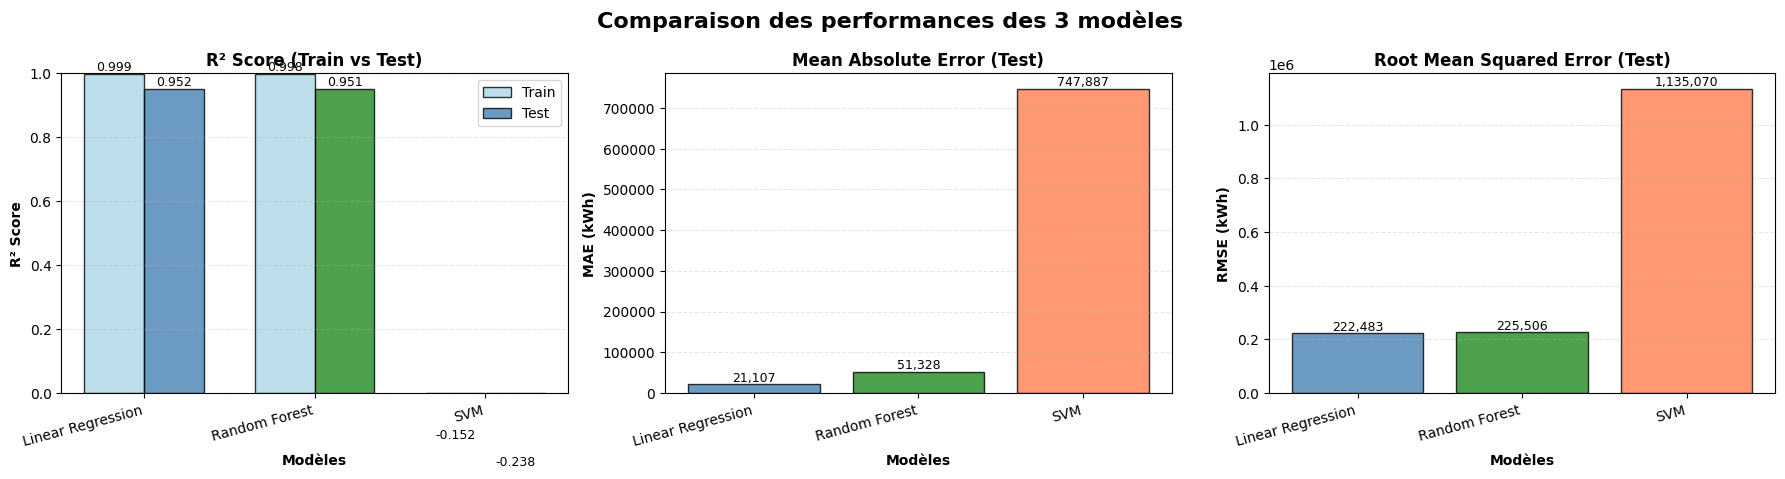

In [369]:
# Créer une figure avec 3 sous-graphiques
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Comparaison des performances des 3 modèles', fontsize=16, fontweight='bold')

models = df_comparison['Modèle'].tolist()
colors = ['steelblue', 'forestgreen', 'coral']

# 1. Comparaison R² (Train vs Test)
ax1 = axes[0]
x_pos = np.arange(len(models))
width = 0.35

r2_train = df_comparison['R² (Train)'].tolist()
r2_test = df_comparison['R² (Test)'].tolist()

bars1 = ax1.bar(x_pos - width/2, r2_train, width, label='Train', alpha=0.8, color='lightblue', edgecolor='black')
bars2 = ax1.bar(x_pos + width/2, r2_test, width, label='Test', alpha=0.8, color=colors, edgecolor='black')

ax1.set_xlabel('Modèles', fontweight='bold')
ax1.set_ylabel('R² Score', fontweight='bold')
ax1.set_title('R² Score (Train vs Test)', fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(models, rotation=15, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_ylim([0, 1])

# Ajouter les valeurs sur les barres
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# 2. Comparaison MAE (Test)
ax2 = axes[1]
mae_test = df_comparison['MAE (Test)'].tolist()
bars = ax2.bar(models, mae_test, color=colors, alpha=0.8, edgecolor='black')

ax2.set_xlabel('Modèles', fontweight='bold')
ax2.set_ylabel('MAE (kWh)', fontweight='bold')
ax2.set_title('Mean Absolute Error (Test)', fontweight='bold')
ax2.set_xticklabels(models, rotation=15, ha='right')
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# Ajouter les valeurs sur les barres
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:,.0f}', ha='center', va='bottom', fontsize=9)

# 3. Comparaison RMSE (Test)
ax3 = axes[2]
rmse_test = df_comparison['RMSE (Test)'].tolist()
bars = ax3.bar(models, rmse_test, color=colors, alpha=0.8, edgecolor='black')

ax3.set_xlabel('Modèles', fontweight='bold')
ax3.set_ylabel('RMSE (kWh)', fontweight='bold')
ax3.set_title('Root Mean Squared Error (Test)', fontweight='bold')
ax3.set_xticklabels(models, rotation=15, ha='right')
ax3.grid(axis='y', alpha=0.3, linestyle='--')

# Ajouter les valeurs sur les barres
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

#### 4.3 Visualisation Prédictions vs Valeurs réelles

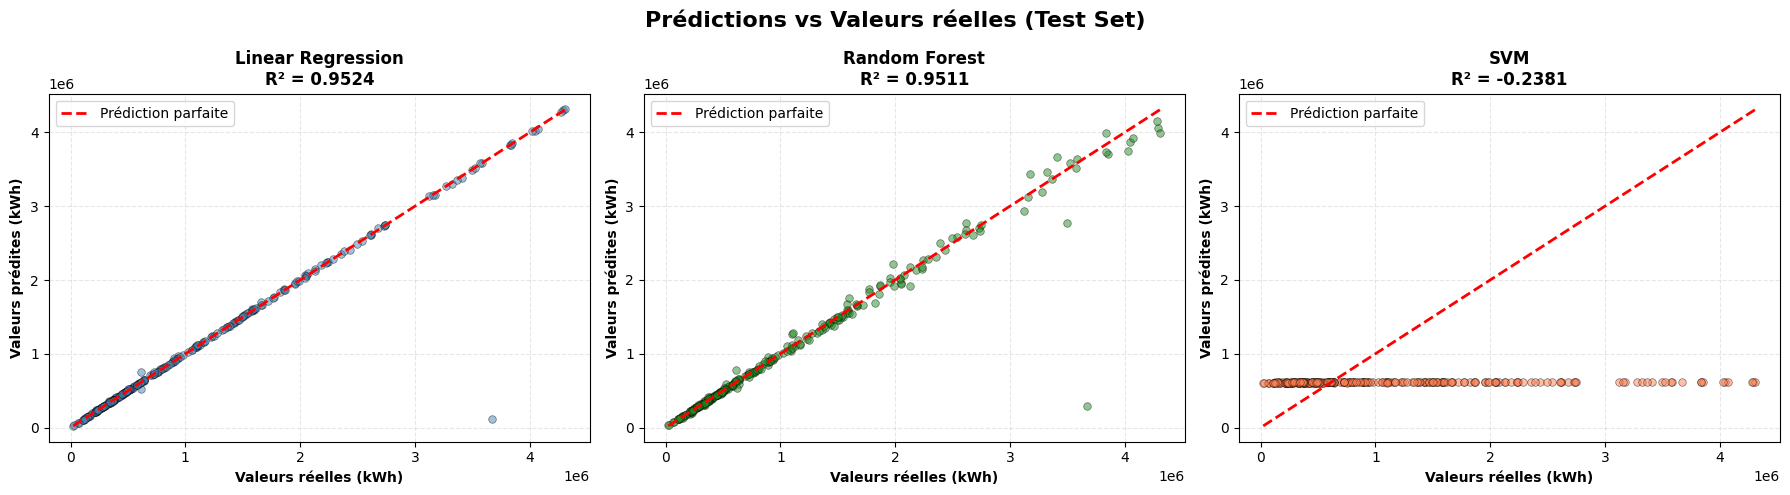

In [370]:
# Visualiser Prédictions vs Valeurs réelles pour les 3 modèles
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Prédictions vs Valeurs réelles (Test Set)', fontsize=16, fontweight='bold')

# Données pour les scatter plots
models_pred = [
    ('Linear Regression', y_test.values.flatten(), y_test_pred_lr, 'steelblue'),
    ('Random Forest', y_test_ravel, y_test_pred_rf, 'forestgreen'),
    ('SVM', y_test_svm, y_test_pred_svm, 'coral')
]

for idx, (model_name, y_true, y_pred, color) in enumerate(models_pred):
    ax = axes[idx]
    
    # Scatter plot
    ax.scatter(y_true, y_pred, alpha=0.5, s=30, color=color, edgecolors='black', linewidth=0.5)
    
    # Ligne de prédiction parfaite (y = x)
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Prédiction parfaite')
    
    # Calculer R² pour afficher
    if model_name == 'Linear Regression':
        r2 = r2_test_lr
    elif model_name == 'Random Forest':
        r2 = r2_test_rf
    else:
        r2 = r2_test_svm
    
    ax.set_xlabel('Valeurs réelles (kWh)', fontweight='bold')
    ax.set_ylabel('Valeurs prédites (kWh)', fontweight='bold')
    ax.set_title(f'{model_name}\nR² = {r2:.4f}', fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

#### 4.4 Distribution des erreurs de prédiction

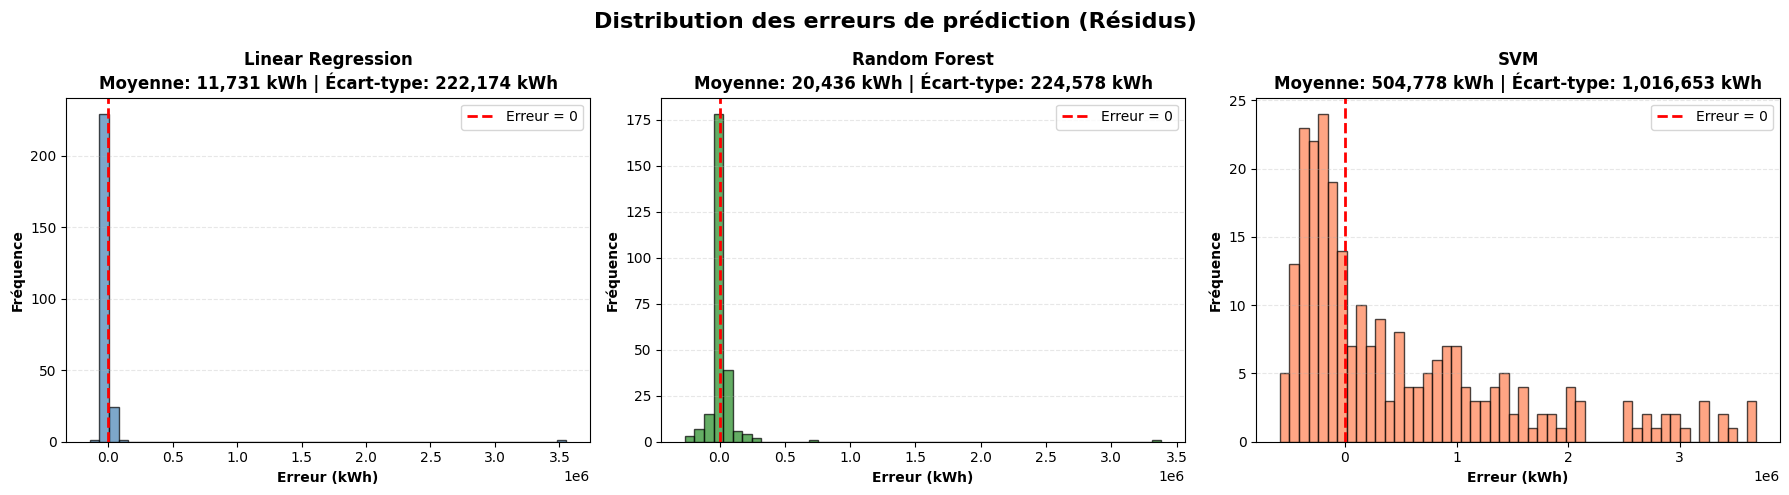

Analyse des erreurs :

Linear Regression:
  Moyenne des erreurs : 11,730.67 kWh
  Écart-type          : 222,173.75 kWh
  Erreur min          : -141,200.96 kWh
  Erreur max          : 3,552,411.93 kWh

Random Forest:
  Moyenne des erreurs : 20,435.76 kWh
  Écart-type          : 224,577.90 kWh
  Erreur min          : -264,546.88 kWh
  Erreur max          : 3,382,710.44 kWh

SVM:
  Moyenne des erreurs : 504,777.70 kWh
  Écart-type          : 1,016,653.04 kWh
  Erreur min          : -582,907.04 kWh
  Erreur max          : 3,686,452.85 kWh


In [371]:
# Distribution des erreurs (résidus) pour chaque modèle
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribution des erreurs de prédiction (Résidus)', fontsize=16, fontweight='bold')

# Calculer les erreurs pour chaque modèle (aplatir pour avoir des tableaux 1D)
errors_lr = (y_test.values.flatten() - y_test_pred_lr.flatten())
errors_rf = (y_test_ravel - y_test_pred_rf.flatten())
errors_svm = (y_test_svm - y_test_pred_svm.flatten())

errors_data = [
    ('Linear Regression', errors_lr, 'steelblue'),
    ('Random Forest', errors_rf, 'forestgreen'),
    ('SVM', errors_svm, 'coral')
]

for idx, (model_name, errors, color) in enumerate(errors_data):
    ax = axes[idx]
    
    # Histogramme des erreurs
    ax.hist(errors, bins=50, alpha=0.7, color=color, edgecolor='black')
    
    # Ligne verticale à 0 (erreur nulle)
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Erreur = 0')
    
    # Statistiques
    mean_error = errors.mean()
    std_error = errors.std()
    
    ax.set_xlabel('Erreur (kWh)', fontweight='bold')
    ax.set_ylabel('Fréquence', fontweight='bold')
    ax.set_title(f'{model_name}\nMoyenne: {mean_error:,.0f} kWh | Écart-type: {std_error:,.0f} kWh', fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("=" * 100)
print("Analyse des erreurs :")
print("=" * 100)
for model_name, errors, _ in errors_data:
    print(f"\n{model_name}:")
    print(f"  Moyenne des erreurs : {errors.mean():,.2f} kWh")
    print(f"  Écart-type          : {errors.std():,.2f} kWh")
    print(f"  Erreur min          : {errors.min():,.2f} kWh")
    print(f"  Erreur max          : {errors.max():,.2f} kWh")


#### 4.5 Synthèse

In [372]:
# Synthèse complète des 3 modèles
print("=" * 100)
print("SYNTHÈSE COMPARATIVE DES 3 MODÈLES")
print("=" * 100)

synthesis_data = {
    'Critère': [
        'R² (Test)',
        'MAE (Test)',
        'RMSE (Test)',
        'Surapprentissage'
    ],
    'Linear Regression': [
        f'{r2_test_lr:.4f}',
        f'{mae_test_lr:,.0f} kWh',
        f'{rmse_test_lr:,.0f} kWh',
        'Bon' if diff_r2 <= 0.1 else 'Attention'
    ],
    'Random Forest': [
        f'{r2_test_rf:.4f}',
        f'{mae_test_rf:,.0f} kWh',
        f'{rmse_test_rf:,.0f} kWh',
        'Bon' if diff_r2_rf <= 0.1 else 'Attention'
    ],
    'SVM': [
        f'{r2_test_svm:.4f}',
        f'{mae_test_svm:,.0f} kWh',
        f'{rmse_test_svm:,.0f} kWh',
        'Bon' if diff_r2_svm <= 0.1 else 'Attention'
    ]
}

df_synthesis = pd.DataFrame(synthesis_data)
display(df_synthesis)

SYNTHÈSE COMPARATIVE DES 3 MODÈLES


,Critère,Linear Regression,Random Forest,SVM
0,R² (Test),0.9524,0.9511,-0.2381
1,MAE (Test),"21,107 kWh","51,328 kWh","747,887 kWh"
2,RMSE (Test),"222,483 kWh","225,506 kWh","1,135,070 kWh"
3,Surapprentissage,Bon,Bon,Bon


---

#### 5. Conclusion

- Le modèle avec le meilleur R² est le modèle par régression linéaire.